In [2]:
from eigsep_data import EigsepData
from eigsep_data import plot
import numpy as np
from eigsep_observing import io
import matplotlib.pyplot as plt
from pathlib import Path
import datetime as dt
%matplotlib notebook

In [485]:
def average_over(data, n):
    d = data.reshape(-1, n)
    nu_data = np.mean(d, axis=1)
    return nu_data

# 09.25
at 1:27, I turned voltage from 4.96V to 5.26V to 5.09V
1:46. turned voltage back to 4.96V

In [760]:
hot_load_data = []
hot_load_T = []
hot_load_lna1 = []
hot_load_lna2 = []
hot_load_ts = []
snap_Ts = []
p = Path('./hot_load_testing0925_1/')
for file in sorted(p.iterdir()):
    data, hdr, meta = io.read_hdf5(file)
    freqs = hdr['freqs']
    try:
        for i in meta['fpga_temp']:
            if i == None:
                snap_Ts.append(0)
            else:
                snap_Ts.append(i['temp_c'])
    except KeyError as e:
        print(e, file)
        continue
        
    hot_load_data.append(data['0'])
    try:
        for i in meta['tempctrl_load']:
            if i != None:
                T_now = i['T_now']
                hot_load_T.append(T_now)
            else:
                hot_load_T.append(0)
    except Exception as e:
        print(e, file)
        
    try:
        for i in meta['tempctrl_lna1']:
            if i != None:
                T_now = i['T_now']
                hot_load_lna1.append(T_now)
            else:
                hot_load_lna1.append(0)
    except Exception as e:
        print(e, file)
        
    try:
        for i in meta['tempctrl_lna2']:
            if i != None:
                T_now = i['T_now']
                hot_load_lna2.append(T_now)
            else:
                hot_load_lna2.append(0)
    except Exception as e:
        print(e, file)
    hot_load_ts.append(hdr['times'])

hot_load_data = np.concatenate(hot_load_data)
hot_load_T = np.array(hot_load_T)
hot_load_lna1 = np.array(hot_load_lna1)
hot_load_lna2 = np.array(hot_load_lna2)
hot_load_ts = np.concatenate(hot_load_ts)
hot_load_hours = (hot_load_ts - hot_load_ts[0])/3600
snap_Ts = np.array(snap_Ts)

timestamps = np.array([dt.datetime.fromtimestamp(t) for t in hot_load_ts])
voltage_change_down = hot_load_hours[timestamps > dt.datetime(2026, 9, 25, 13, 27, 0, 0)][0]
voltage_change_up = hot_load_hours[timestamps > dt.datetime(2026, 9, 25, 13, 45, 0, 0)][0]

<IPython.core.display.Javascript object>


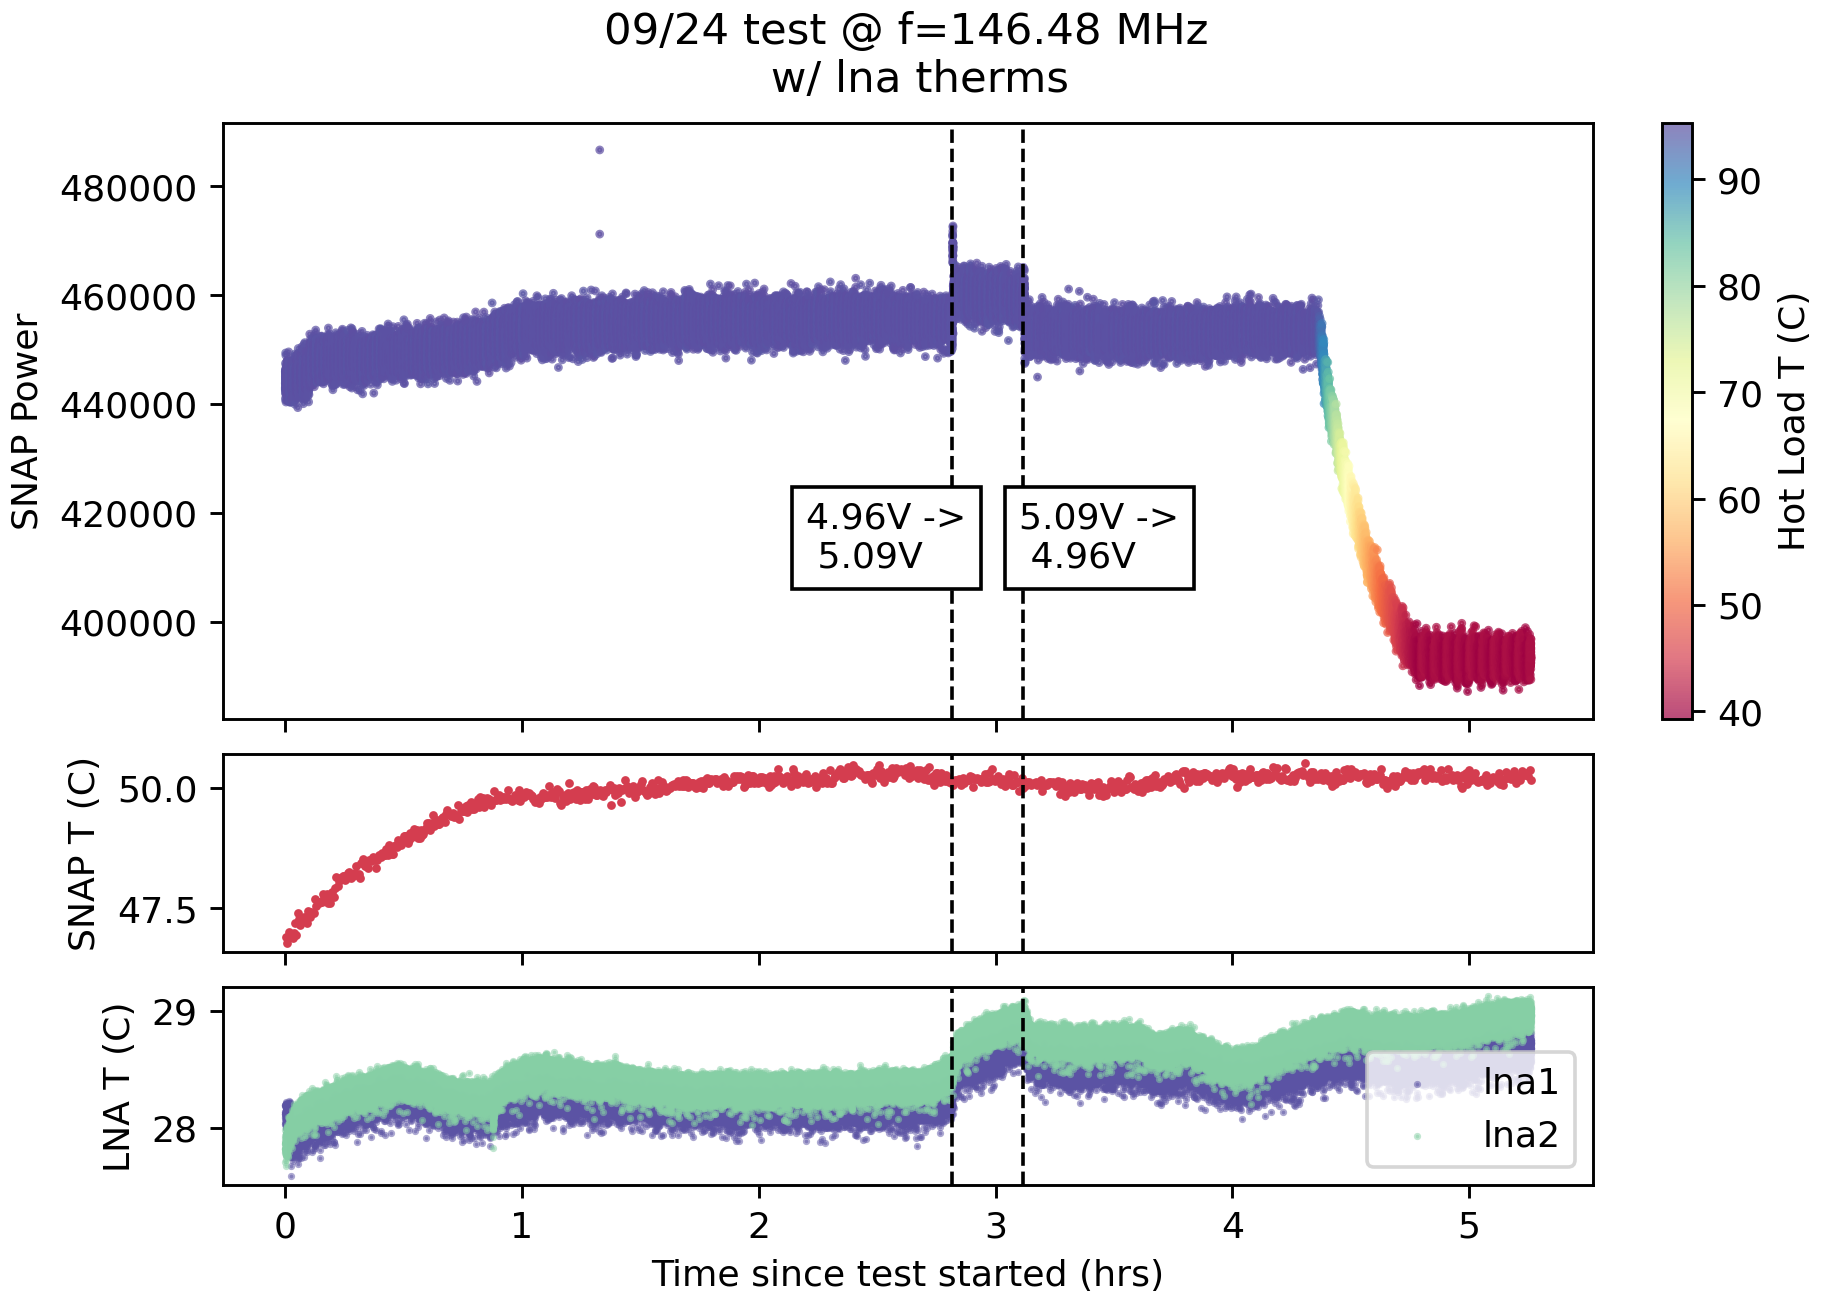

In [770]:
nch = 600
idx=0
min_temp = 0
max_temp=110
hot_load_data1 = hot_load_data[idx:]
hot_load_hours1 = hot_load_hours[idx:]
hot_load_T1 = hot_load_T[idx:]
hot_load_lna1_1 = hot_load_lna1[idx:]
hot_load_lna2_1 = hot_load_lna2[idx:]
snap_Ts1 = snap_Ts[idx:]
condition = (hot_load_T1 > min_temp) * (hot_load_T1 < max_temp)
cmap = plt.colormaps["Spectral"]

color1 = cmap(0.1)
color2 = cmap(0.99)
color3 = cmap(0.75)

fig, ax = plt.subplots(nrows=3, figsize=(7,5), sharex=True, layout='constrained', height_ratios=(3,1,1))
scat = ax[0].scatter(hot_load_hours1[condition], hot_load_data1[condition][:,nch], c=hot_load_T1[condition], cmap=cmap, s=2, alpha=0.7)
ax[0].set_ylabel('SNAP Power')
cbar = plt.colorbar(label='Hot Load T (C)', mappable=scat)
ax[0].axvline(voltage_change_down, color='black', linewidth=1, alpha=1, linestyle='--')
ax[0].axvline(voltage_change_up, color='black', linewidth=1, alpha=1, linestyle='--')
ax[0].text(2.2, 410000, '4.96V ->\n 5.09V', bbox={'facecolor':'white', 'edgecolor':'black', 'alpha':1})
ax[0].text(3.1, 410000, '5.09V ->\n 4.96V', bbox={'facecolor':'white', 'edgecolor':'black', 'alpha':1})

ax[1].set_ylabel('SNAP T (C)')
ax[1].scatter(hot_load_hours1[snap_Ts1 > 0], snap_Ts1[snap_Ts1 > 0], s=2, color=color1)
ax[1].axvline(voltage_change_down, color='black', linewidth=1, alpha=1, linestyle='--')
ax[1].axvline(voltage_change_up, color='black', linewidth=1, alpha=1, linestyle='--')

ax[2].scatter(hot_load_hours1[hot_load_lna1_1 > 0], hot_load_lna1_1[hot_load_lna1_1 > 0], s=1, color=color2, alpha=0.5, label='lna1')
ax[2].scatter(hot_load_hours1[hot_load_lna2_1 > 0], hot_load_lna2_1[hot_load_lna2_1 > 0], s=1, color=color3, alpha=0.5, label='lna2')
ax[2].axvline(voltage_change_down, color='black', linewidth=1, alpha=1, linestyle='--')
ax[2].axvline(voltage_change_up, color='black', linewidth=1, alpha=1, linestyle='--')
ax[2].set_xlabel('Time since test started (hrs)')
ax[2].set_ylabel('LNA T (C)')
ax[2].legend()

plt.suptitle(f'09/24 test @ f={freqs[nch]:.2f} MHz \n w/ lna therms')
plt.savefig('hot_load_0925.jpg', dpi=300)
plt.show()

<IPython.core.display.Javascript object>


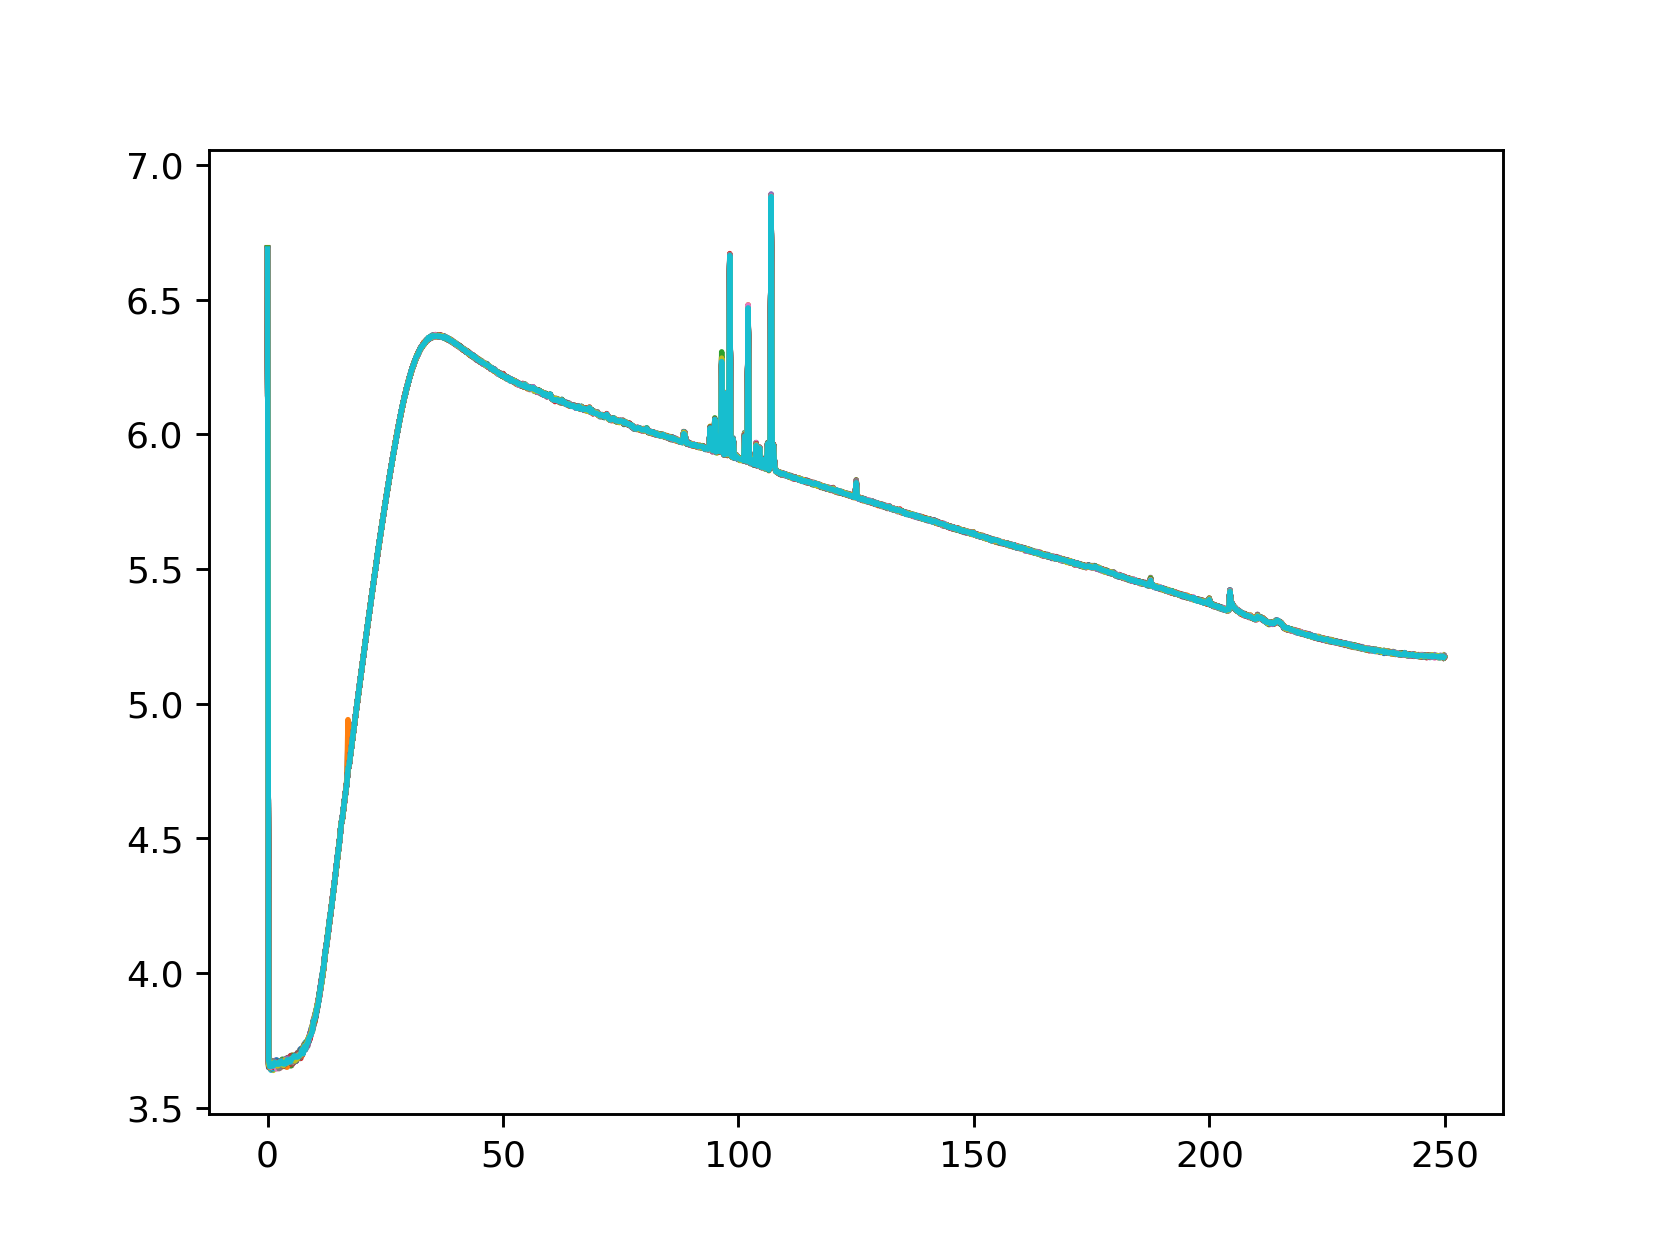

In [677]:
plt.figure()
plt.plot(freqs, np.log10(np.abs(hot_load_data1[condition][:50].T)))
# plt.plot(freqs, np.log10(np.abs(hot_load_data1[condition][-50:])).T)
# plt.plot(freqs, np.log10(np.abs(hot_load_data1[condition][int(len(hot_load_data1)/2) : int(len(hot_load_data1)/2) + 50].T)))
# plt.plot(freqs, np.log10(np.abs(hot_load_data1[condition][int(len(hot_load_data1)/3) : int(len(hot_load_data1)/3) + 50].T)))
plt.show()

In [541]:
plt.close('all')

In [3]:
from eigsep_cal import S11

In [33]:
s11_stuff = S11('switch_bench_tests/ants11_20261009_015002Z.h5')

<IPython.core.display.Javascript object>


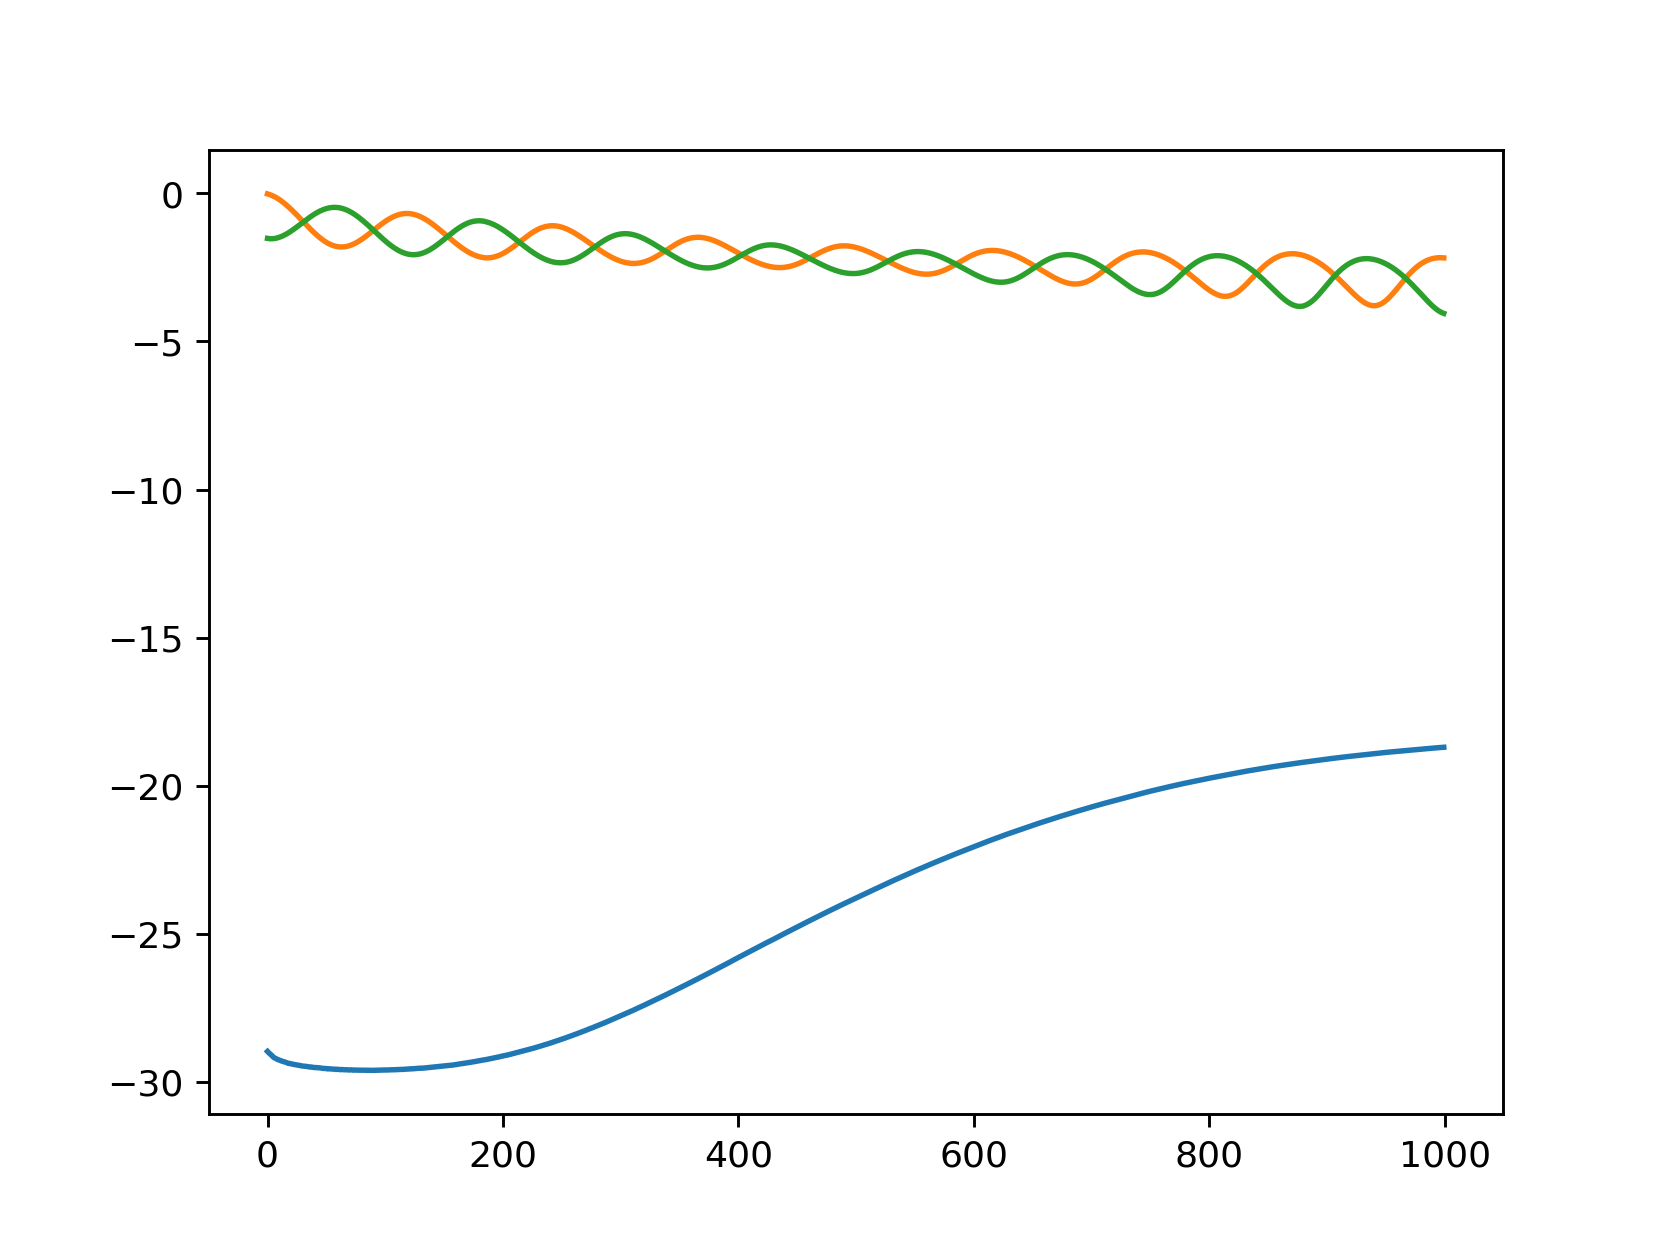

<IPython.core.display.Javascript object>


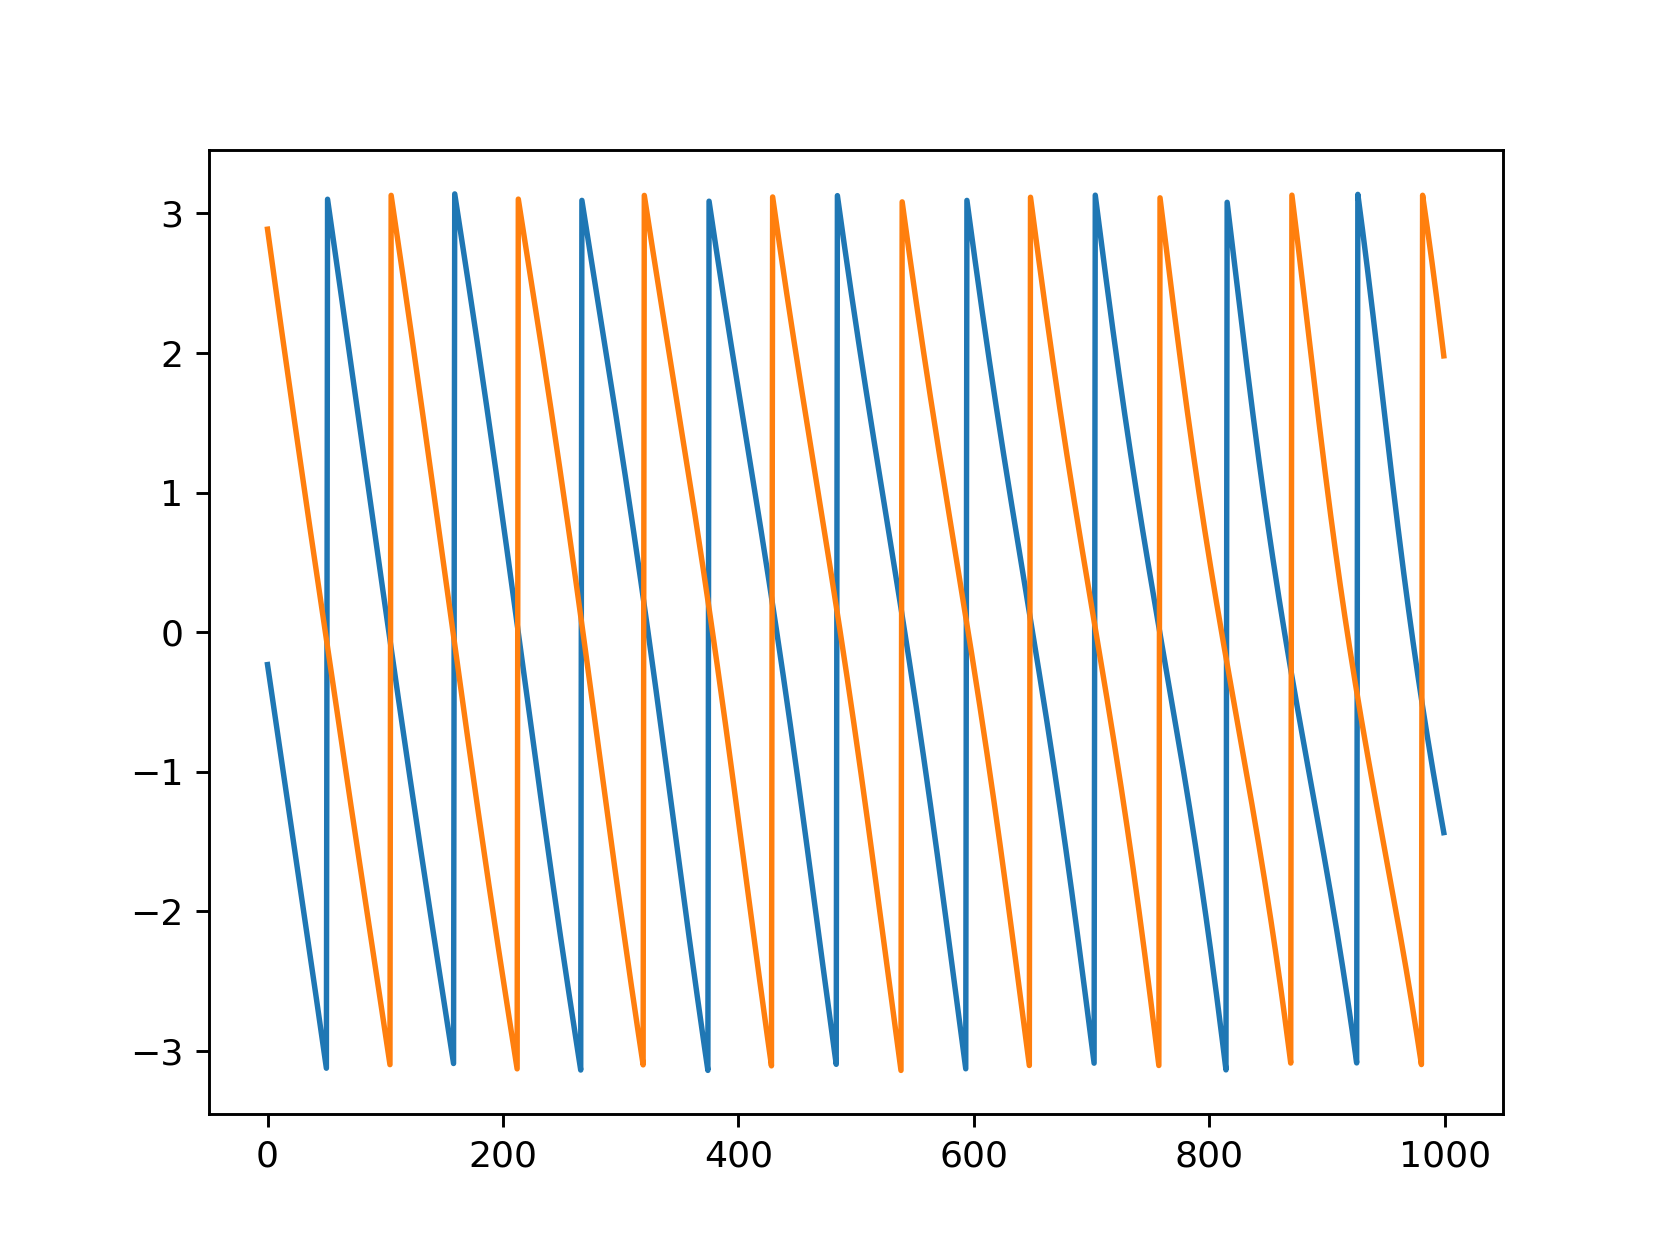

In [34]:
ant_s11 = s11_stuff.get_all_s11s(dut='ant', plane='raw')[1][0]
sp1o_s11 = s11_stuff.get_all_s11s(dut='sp1_open', plane='raw')[1][0]
sp1s_s11 = s11_stuff.get_all_s11s(dut='sp1_short', plane='raw')[1][0]
plt.figure()
plt.plot(20*np.log10(np.abs(ant_s11)))
plt.plot(20*np.log10(np.abs(sp1o_s11)))
plt.plot(20*np.log10(np.abs(sp1s_s11)))
plt.show()
plt.figure()
plt.plot(np.angle(sp1o_s11))
plt.plot(np.angle(sp1s_s11))
plt.show()